In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

In [3]:
df = pd.read_csv('rawdata.csv')

print(df.head())

print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

## Data Cleaning

In [4]:
#Turned specific columns into numerical variable 
df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].replace({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].replace({'Male': 1, 'Female': 0})
print(df[['Attrition', 'OverTime', 'Gender']].head())

  Attrition OverTime Gender
0         1        1      0
1         0        0      1
2         1        1      1
3         0        1      0
4         0        0      1


In [5]:
#removing unecessary data
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=drop_cols)

In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing values: 0
Duplicates: 0


In [7]:
print(df.head())
print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41         1      Travel_Rarely       1102                   Sales   
1   49         0  Travel_Frequently        279  Research & Development   
2   37         1      Travel_Rarely       1373  Research & Development   
3   33         0  Travel_Frequently       1392  Research & Development   
4   27         0      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction Gender  \
0                 1          2  Life Sciences                        2      0   
1                 8          1  Life Sciences                        3      1   
2                 2          2          Other                        4      1   
3                 3          4  Life Sciences                        4      0   
4                 2          1        Medical                        1      1   

   ...  PerformanceRating  RelationshipSatisfaction  StockOptionLeve

In [8]:
# checking Class Imbalance
attrition_counts = df['Attrition'].value_counts()
attrition_pcts = df['Attrition'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({
    'Count': attrition_counts,
    'Percentage (%)': attrition_pcts.round(2)
})
print("\nAttrition:")
print(imbalance_summary)


Attrition:
           Count  Percentage (%)
Attrition                       
0           1233           83.88
1            237           16.12


In [9]:
print(" Attrition ανά Τμήμα ")
print((df.groupby('Department')['Attrition'].mean() * 100).sort_values(ascending=False).round(2))

print("\n Attrition ανά Ρόλο Εργασίας ")
print((df.groupby('JobRole')['Attrition'].mean() * 100).sort_values(ascending=False).round(2))

 Attrition ανά Τμήμα 
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: object

 Attrition ανά Ρόλο Εργασίας 
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist            16.1
Manufacturing Director         6.9
Healthcare Representative     6.87
Manager                        4.9
Research Director              2.5
Name: Attrition, dtype: object


In [11]:
focus_cats = ['Department', 'JobRole', 'JobLevel', 'EnvironmentSatisfaction', 'PerformanceRating']
for i in focus_cats:
    print(f"\n Attrition ανά {i} ")
    summary = df.groupby(i)['Attrition'].agg(
        Headcount='count', #πλήθος γραμμών
        Attrition_Count='sum', #πόσοι έφυγαν
        Attrition_Rate=lambda x: (x.mean() * 100).round(2) #ποσοστό αποχώρησης
    ).reset_index()
    print(summary.sort_values(by='Attrition_Rate', ascending=False).to_string(index=False))


 Attrition ανά Department 
            Department  Headcount Attrition_Count  Attrition_Rate
                 Sales        446              92           20.63
       Human Resources         63              12           19.05
Research & Development        961             133           13.84

 Attrition ανά JobRole 
                  JobRole  Headcount Attrition_Count  Attrition_Rate
     Sales Representative         83              33           39.76
    Laboratory Technician        259              62           23.94
          Human Resources         52              12           23.08
          Sales Executive        326              57           17.48
       Research Scientist        292              47           16.10
   Manufacturing Director        145              10            6.90
Healthcare Representative        131               9            6.87
                  Manager        102               5            4.90
        Research Director         80               2          

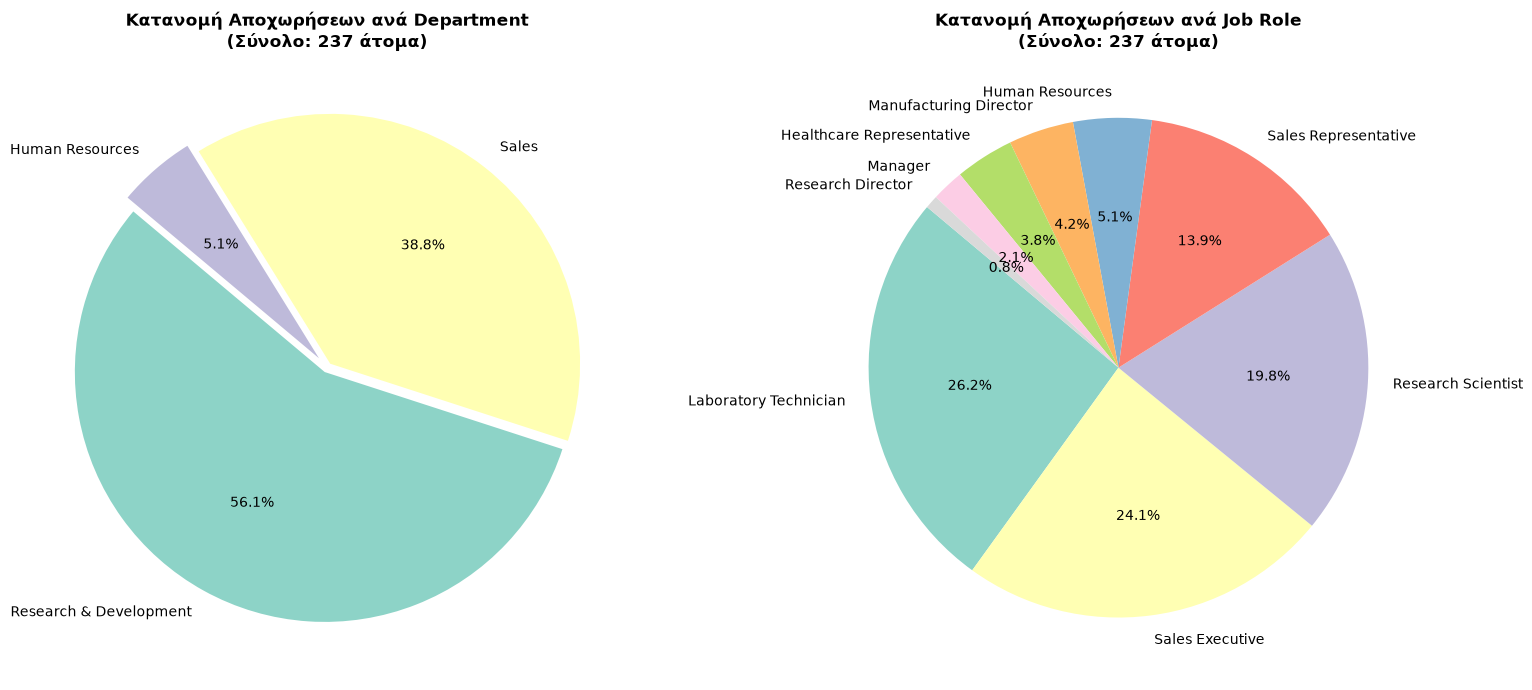

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.get_cmap('Set3')

dept_attr = df[df['Attrition'] == 1]['Department'].value_counts()
dept_colors = [cmap(i) for i in range(len(dept_attr))]

axes[0].pie(
    dept_attr, 
    labels=dept_attr.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=dept_colors,
    explode=[0.02, 0.02, 0.05]
)
axes[0].set_title('Κατανομή Αποχωρήσεων ανά Department\n(Σύνολο: 237 άτομα)', fontsize=12, fontweight='bold')

role_attr = df[df['Attrition'] == 1]['JobRole'].value_counts()
role_colors = [cmap(i % 12) for i in range(len(role_attr))]  

axes[1].pie(
    role_attr, 
    labels=role_attr.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=role_colors
)
axes[1].set_title('Κατανομή Αποχωρήσεων ανά Job Role\n(Σύνολο: 237 άτομα)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# 1. PerformanceRating & OverTime
print("Attrition Rate ανά Performance & OverTime ---")
cross_perf = df.groupby(['PerformanceRating', 'OverTime'])['Attrition'].agg(
    Headcount='count',
    Attrition_Rate=lambda x: (x.mean() * 100).round(2)
).reset_index()
print(cross_perf.to_string(index=False))

print("\n Attrition Rate ανά JobInvolvement ")
cross_involv = df.groupby('JobInvolvement')['Attrition'].agg(
    Headcount='count',
    Attrition_Rate=lambda x: (x.mean() * 100).round(2)
).reset_index()
print(cross_involv.to_string(index=False))

Attrition Rate ανά Performance & OverTime ---
 PerformanceRating  OverTime  Headcount  Attrition_Rate
                 3         0        893           10.75
                 3         1        351           29.63
                 4         0        161            8.70
                 4         1         65           35.38

 Attrition Rate ανά JobInvolvement 
 JobInvolvement  Headcount  Attrition_Rate
              1         83           33.73
              2        375           18.93
              3        868           14.40
              4        144            9.03


### Συμπεράσματα

#### Performance & OverTime
* **Κίνδυνος Burnout στα Κορυφαία Στελέχη:** Το απλό `PerformanceRating` από μόνο του δεν δείχνει διαφορά στην αποχώρηση (16%), αλλά σε συνδυασμό με τις υπερωρίες αλλάζει δραματικά:
  * Στους υπαλλήλους με **υψηλή απόδοση (Rating 4)** που **κάνουν υπερωρίες (OverTime = 1)**, το ποσοστό φυγής εκτοξεύεται στο **35.38%**, **8.70%** όσων δεν κάνουν υπερωρίες (αύξηση X4).
  * Αντίστοιχα, στο **Rating 3**, οι υπερωρίες τριπλασιάζουν την πιθανότητα αποχώρησης από **10.75%** σε **29.63%**.
* **Συμπέρασμα:** Η εταιρεία χάνει τα πιο παραγωγικά της στελέχη κυρίως λόγω εξουθένωσης από υπερωρίες.

#### 2. Βαθμός Εμπλοκής στην Εργασία (Job Involvement)
* **Αντιστρόφως Ανάλογη Σχέση:** Όσο μειώνεται το ενδιαφέρον/δέσμευση του εργαζομένου για τη δουλειά του, τόσο αυξάνεται ραγδαία η αποχώρηση:
  * **Επίπεδο 1 (Πολύ χαμηλή εμπλοκή):** Αποχωρεί το **33.73%** (1 στους 3).
  * **Επίπεδο 2 (Μέτρια εμπλοκή):** Αποχωρεί το **18.93%**.
  * **Επίπεδο 3 (Υψηλή εμπλοκή):** Αποχωρεί το **14.40%**.
  * **Επίπεδο 4 (Πολύ υψηλή εμπλοκή):** Αποχωρεί μόλις το **9.03%**.
* **Συμπέρασμα:** Η έλλειψη κινήτρων και εμπλοκής στα πρώιμα στάδια αποτελεί το πιο αξιόπιστο καμπανάκι κινδύνου για μελλοντική παραίτηση.

C:\Users\Konst\AppData\Local\Temp\ipykernel_23908\4072467900.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


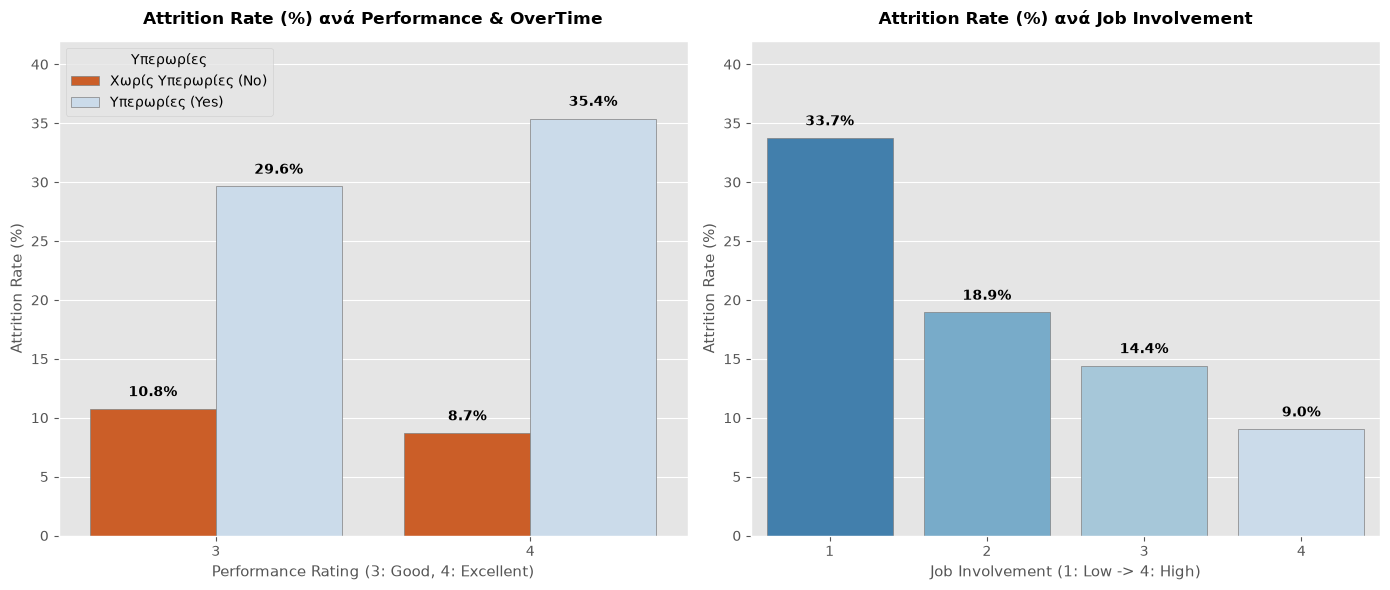

In [16]:
plt.style.use('ggplot')
cmap2 = plt.get_cmap('tab20c')
set3_colors = [cmap2(i) for i in range(12)]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

perf_ot = df.groupby(['PerformanceRating', 'OverTime'])['Attrition'].mean().reset_index()
perf_ot['Attrition_Rate'] = perf_ot['Attrition'] * 100
perf_ot['OverTime_Label'] = perf_ot['OverTime'].map({1: 'Υπερωρίες (Yes)', 0: 'Χωρίς Υπερωρίες (No)'})

sns.barplot(
    ax=axes[0],
    data=perf_ot,
    x='PerformanceRating',
    y='Attrition_Rate',
    hue='OverTime_Label',
    palette=[set3_colors[4], set3_colors[3]],
    edgecolor='gray'
)
axes[0].set_title('Attrition Rate (%) ανά Performance & OverTime', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Performance Rating (3: Good, 4: Excellent)', fontsize=11)
axes[0].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[0].set_ylim(0, 42)
axes[0].legend(title='Υπερωρίες')

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height + 0.8),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

job_inv = df.groupby('JobInvolvement')['Attrition'].mean().reset_index()
job_inv['Attrition_Rate'] = job_inv['Attrition'] * 100

sns.barplot(
    ax=axes[1],
    data=job_inv,
    x='JobInvolvement',
    y='Attrition_Rate',
    palette=[set3_colors[i] for i in range(4)],
    edgecolor='gray'
)
axes[1].set_title('Attrition Rate (%) ανά Job Involvement', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Job Involvement (1: Low -> 4: High)', fontsize=11)
axes[1].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[1].set_ylim(0, 42)

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height + 0.8),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

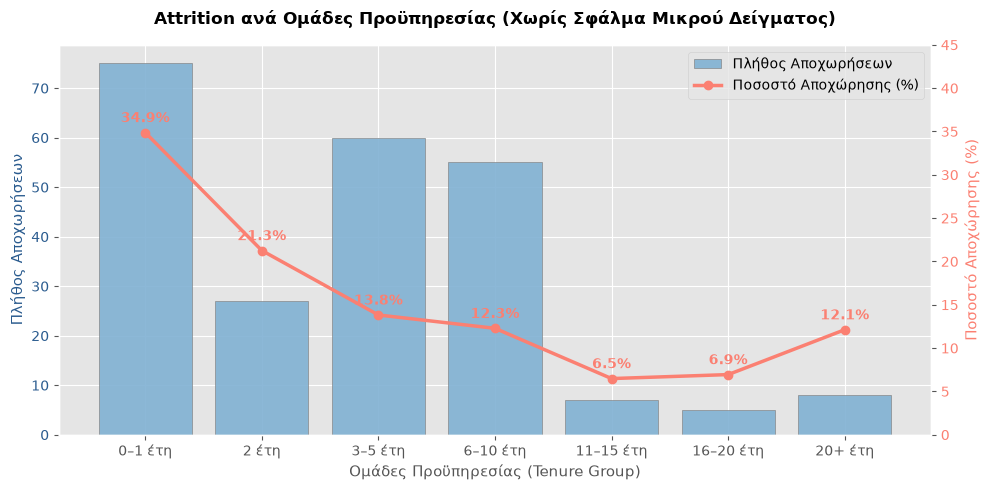

In [22]:
bins = [0, 1, 2, 5, 10, 15, 20, 45]
labels = ['0–1 έτη', '2 έτη', '3–5 έτη', '6–10 έτη', '11–15 έτη', '16–20 έτη', '20+ έτη']
df['Tenure_Group'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels, include_lowest=True, right=True)

binned = df.groupby('Tenure_Group', observed=True)['Attrition'].agg(
    Headcount='count',
    Attritions='sum',
    Attrition_Rate=lambda x: (x.mean() * 100).round(2) # Ανώνυμη συνάρτηση για μετατροπή του μέσου όρου (0/1)
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(binned['Tenure_Group'], binned['Attritions'], color=cmap(4), edgecolor='gray', alpha=0.9, label='Πλήθος Αποχωρήσεων')
ax1.set_xlabel('Ομάδες Προϋπηρεσίας (Tenure Group)', fontsize=11)
ax1.set_ylabel('Πλήθος Αποχωρήσεων', fontsize=11, color='#2b5c8f')
ax1.tick_params(axis='y', labelcolor='#2b5c8f')

ax2 = ax1.twinx()
ax2.plot(binned['Tenure_Group'], binned['Attrition_Rate'], color=cmap(3), marker='o', linewidth=2.5, label='Ποσοστό Αποχώρησης (%)')
ax2.set_ylabel('Ποσοστό Αποχώρησης (%)', fontsize=11, color=cmap(3))
ax2.tick_params(axis='y', labelcolor=cmap(3))
ax2.set_ylim(0, 45)
ax2.grid(False)

for i, txt in enumerate(binned['Attrition_Rate']):
    ax2.annotate(f'{txt:.1f}%', (i, txt + 1.2), ha='center', fontsize=10, fontweight='bold', color=cmap(3))

plt.title('Attrition ανά Ομάδες Προϋπηρεσίας (Χωρίς Σφάλμα Μικρού Δείγματος)', fontsize=12, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

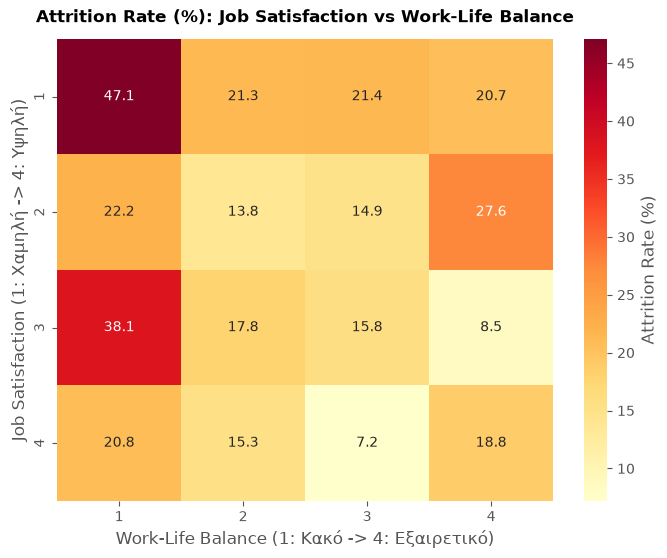

In [ ]:
pivot_sat_wlb = df.pivot_table(
    index='JobSatisfaction', 
    columns='WorkLifeBalance', 
    values='Attrition', 
    aggfunc=lambda x: (x.mean() * 100).round(1)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_sat_wlb, 
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd', 
    cbar_kws={'label': 'Attrition Rate (%)'}
)
plt.title('Attrition Rate (%): Job Satisfaction vs Work-Life Balance', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Work-Life Balance (1 Κακό -> 4 Εξαιρετικό)')
plt.ylabel('Job Satisfaction (1 Χαμηλή -> 4 Υψηλή)')
plt.show()